In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

print("Librairies chargées ✅")

Librairies chargées ✅


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/kgueye/online-retail/online_retail_II.csv')
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
print(f"Période : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Pays uniques : {df['Country'].nunique()}")
print(f"Clients uniques : {df['Customer ID'].nunique()}")

Période : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Pays uniques : 43
Clients uniques : 5942


In [6]:
# Suppression des lignes sans Customer ID
df = df.dropna(subset=['Customer ID'])

# Conversion des types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

# Suppression des quantités négatives (retours/annulations)
df = df[df['Quantity'] > 0]

# Suppression des prix nuls ou négatifs
df = df[df['Price'] > 0]

# Suppression des factures d'annulation (commencent par 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(f"Lignes restantes : {len(df)}")
print(f"Clients uniques : {df['Customer ID'].nunique()}")

Lignes restantes : 805549
Clients uniques : 5878


## Nettoyage des données

- Suppression des lignes sans Customer ID : -243 007 lignes
- Suppression des quantités négatives (retours)
- Suppression des prix nuls
- Suppression des factures annulées (préfixe 'C')
- Conversion InvoiceDate en datetime
- Résultat : 805 549 lignes, 5 878 clients identifiés

In [7]:
# Date de référence = lendemain de la dernière transaction
date_ref = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Date de référence : {date_ref}")

# Calcul du montant par ligne
df['TotalPrice'] = df['Quantity'] * df['Price']

# Agrégation par client
rfm = df.groupby('Customer ID').agg(
    Recence    = ('InvoiceDate', lambda x: (date_ref - x.max()).days),
    Frequence  = ('Invoice', 'nunique'),
    Montant    = ('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.head(10)

Date de référence : 2011-12-10 12:50:00
(5878, 4)


,Customer ID,Recence,Frequence,Montant
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [8]:
rfm.describe().round(2)

,Customer ID,Recence,Frequence,Montant
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,3018.62
std,1715.57,209.34,13.01,14737.73
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,348.76
50%,15314.50,96.00,3.00,898.92
75%,16797.75,380.00,7.00,2307.09
max,18287.00,739.00,398.00,608821.65


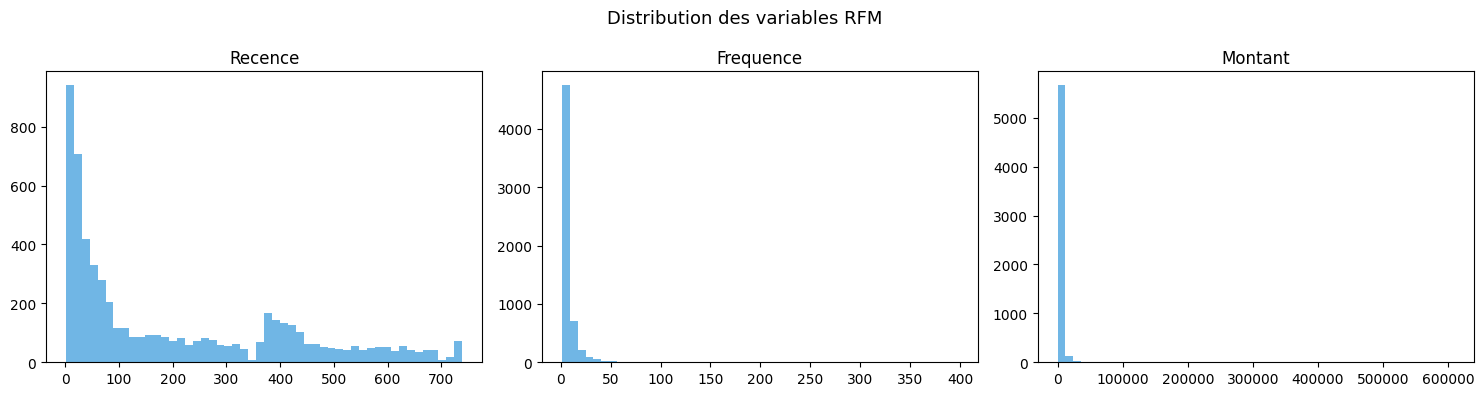

In [9]:
# Distribution des 3 variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recence', 'Frequence', 'Montant']):
    axes[['Recence', 'Frequence', 'Montant'].index(col)].hist(
        rfm[col], bins=50, color='#3498db', alpha=0.7)
    ax.set_title(col)
plt.suptitle('Distribution des variables RFM', fontsize=13)
plt.tight_layout()
plt.show()

### Distributions RFM

- Fréquence et Montant : distributions très asymétriques (longue queue à droite)
- Montant max : 608 821€ → outlier massif
- Transformation logarithmique nécessaire avant clustering

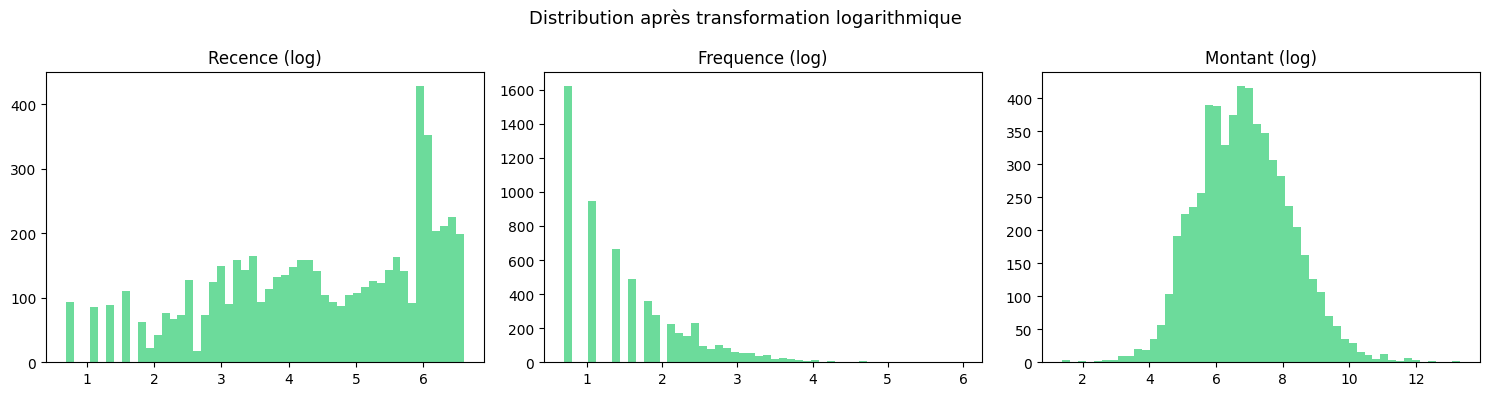

In [10]:
# Transformation logarithmique
rfm_log = rfm.copy()
rfm_log['Recence']   = np.log1p(rfm['Recence'])
rfm_log['Frequence'] = np.log1p(rfm['Frequence'])
rfm_log['Montant']   = np.log1p(rfm['Montant'])

# Visualisation après transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recence', 'Frequence', 'Montant']):
    axes[['Recence', 'Frequence', 'Montant'].index(col)].hist(
        rfm_log[col], bins=50, color='#2ecc71', alpha=0.7)
    ax.set_title(f'{col} (log)')
plt.suptitle('Distribution après transformation logarithmique', fontsize=13)
plt.tight_layout()
plt.show()

### Après transformation logarithmique

- Montant : distribution quasi-normale après log → excellent
- Recence : distribution plus étalée, deux modes visibles
- Frequence : encore légèrement asymétrique mais acceptable
- Les données sont maintenant prêtes pour le clustering

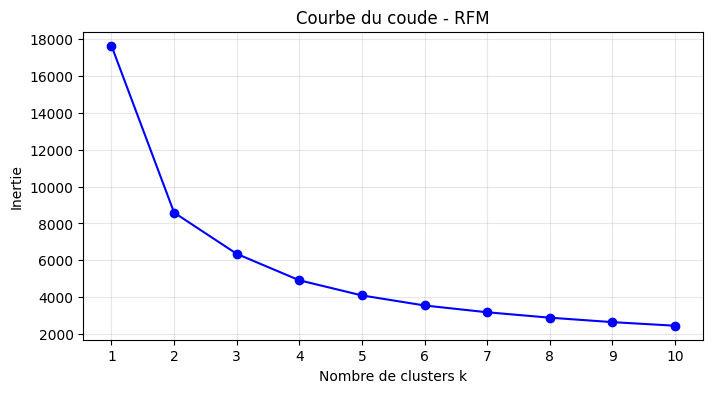

In [11]:
# Normalisation
X_rfm = rfm_log[['Recence', 'Frequence', 'Montant']].values
scaler = StandardScaler()
X_rfm_scaled = scaler.fit_transform(X_rfm)

# Courbe du coude
inerties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rfm_scaled)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inerties, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Courbe du coude - RFM')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

In [12]:
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    score = silhouette_score(X_rfm_scaled, labels)
    print(f'k={k} → Silhouette Score : {score:.3f}')

k=3 → Silhouette Score : 0.348
k=4 → Silhouette Score : 0.365
k=5 → Silhouette Score : 0.342


### Courbe du coude - RFM

- k=3 : 0.348 / k=4 : 0.365 / k=5 : 0.342
- On retient k=4 (meilleur Silhouette Score)
- Scores plus faibles qu'un dataset pédagogique → normal sur données réelles

In [13]:
# KMeans final
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X_rfm_scaled)

# Profilage
profil = rfm.groupby('Cluster').agg(
    Recence_moy   = ('Recence',   'mean'),
    Frequence_moy = ('Frequence', 'mean'),
    Montant_moy   = ('Montant',   'mean'),
    Nb_clients    = ('Customer ID', 'count')
).round(1)

print(profil)

         Recence_moy  Frequence_moy  Montant_moy  Nb_clients
Cluster                                                     
0               27.4           19.3      11014.4        1188
1              395.9            1.4        325.7        1974
2              227.9            5.1       2002.1        1465
3               28.4            3.0        865.1        1251


### Profilage des segments RFM (k=4)

- Cluster 0 : récents, très fréquents, gros montants → Champions
- Cluster 1 : inactifs depuis ~1 an, 1 seule commande → Clients perdus
- Cluster 2 : inactifs depuis ~8 mois, montant moyen → Clients à risque
- Cluster 3 : récents, peu fréquents, petit montant → Nouveaux prometteurs

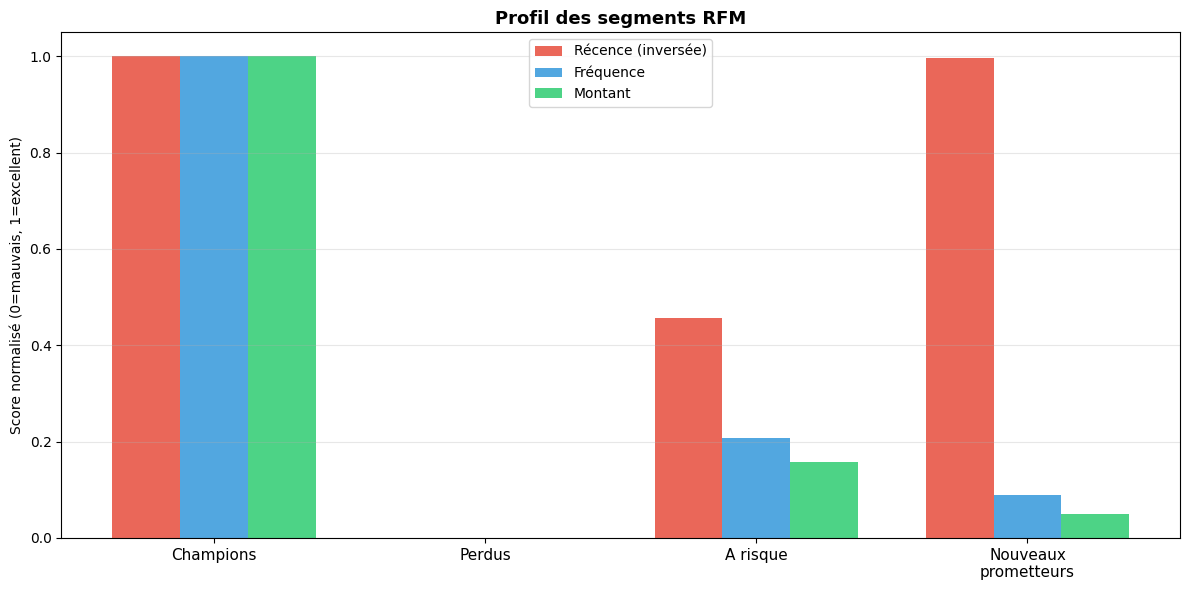

In [14]:
segments = ['Champions', 'Perdus', 'A risque', 'Nouveaux\nprometteurs']
recence =   [27.4,  395.9, 227.9, 28.4]
frequence = [19.3,  1.4,   5.1,   3.0]
montant =   [11014, 326,   2002,  865]

# Normalisation pour comparaison visuelle
from sklearn.preprocessing import MinMaxScaler
data = np.array([recence, frequence, montant]).T
data_norm = MinMaxScaler().fit_transform(data)

# Inversion de la Récence : plus c'est haut = plus c'est récent = mieux
recence_inv = [1 - r for r in data_norm[:, 0]]

x = np.arange(len(segments))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, recence_inv,    width, label='Récence (inversée)', color='#e74c3c', alpha=0.85)
ax.bar(x,         data_norm[:, 1], width, label='Fréquence',          color='#3498db', alpha=0.85)
ax.bar(x + width, data_norm[:, 2], width, label='Montant',            color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(segments, fontsize=11)
ax.set_ylabel('Score normalisé (0=mauvais, 1=excellent)')
ax.set_title('Profil des segments RFM', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Profil des segments RFM

- Champions : score maximal sur les 3 dimensions
- Perdus : inactifs, score minimal → réactivation difficile
- A risque : encore présents mais signal de départ
- Nouveaux prometteurs : récents mais pas encore engagés

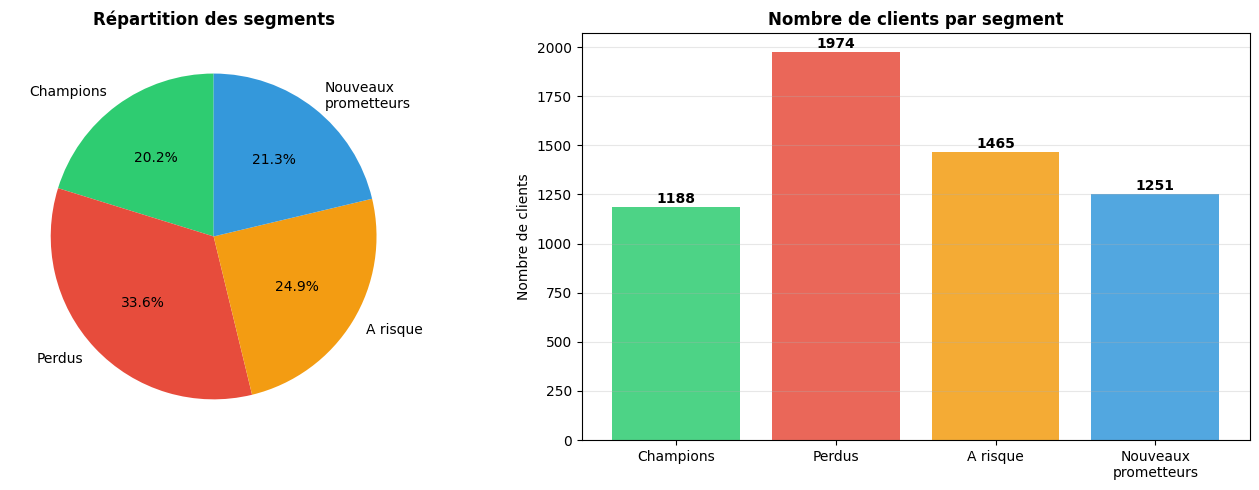

In [15]:
tailles = profil['Nb_clients'].tolist()
segments = ['Champions', 'Perdus', 'A risque', 'Nouveaux\nprometteurs']
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(tailles, labels=segments, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Répartition des segments', fontweight='bold')

# Bar chart
bars = axes[1].bar(segments, tailles, color=colors, alpha=0.85)
for bar, taille in zip(bars, tailles):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 20,
                 str(taille), ha='center', fontweight='bold')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Nombre de clients par segment', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Répartition des segments

- Champions : 1 188 clients (20.2%)
- Perdus : 1 974 clients (33.6%) → segment le plus large
- A risque : 1 465 clients (24.9%)
- Nouveaux prometteurs : 1 251 clients (21.3%)

Plus d'un tiers des clients sont inactifs.
Les segments A risque et Perdus représentent 58.5% de la base.

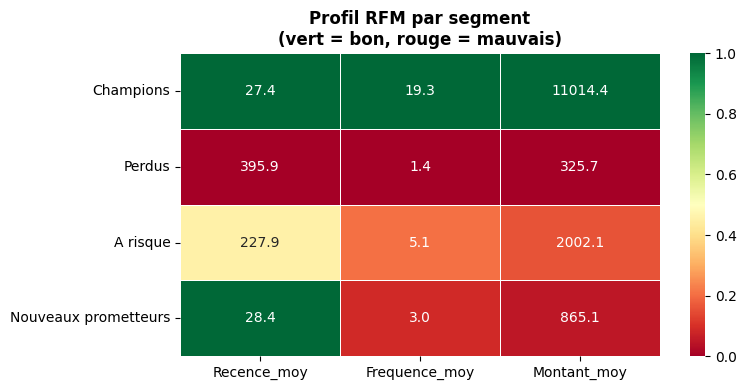

In [16]:
heatmap_data = profil[['Recence_moy', 'Frequence_moy', 'Montant_moy']].copy()
heatmap_data.index = ['Champions', 'Perdus', 'A risque', 'Nouveaux prometteurs']

from sklearn.preprocessing import MinMaxScaler
heatmap_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)
fig, ax = plt.subplots(figsize=(8, 4))

heatmap_correct = heatmap_norm.copy()
heatmap_correct['Recence_moy'] = 1 - heatmap_norm['Recence_moy']

sns.heatmap(heatmap_correct, annot=heatmap_data.round(1), 
            fmt='', cmap='RdYlGn',
            linewidths=0.5, ax=ax,
            vmin=0, vmax=1)

ax.set_title('Profil RFM par segment\n(vert = bon, rouge = mauvais)', 
             fontweight='bold')
plt.tight_layout()
plt.show()

### Heatmap RFM

Lecture : vert = bon, rouge = mauvais.
La Récence a été inversée pour une lecture cohérente.

- Champions : profil optimal sur les 3 dimensions
- Perdus : profil le plus faible, inactifs depuis ~1 an
- A risque : récence encore acceptable mais engagement faible
- Nouveaux prometteurs : récents mais pas encore fidélisés

Variance expliquée : [0.76372366 0.18766172]
Total : 95.14%


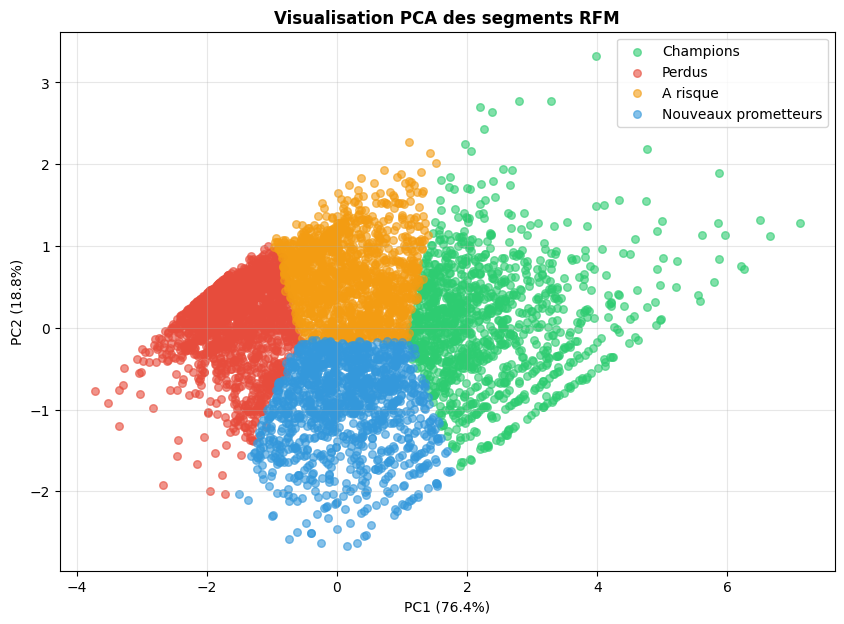

In [17]:
from sklearn.decomposition import PCA

# PCA en 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfm_scaled)

print(f'Variance expliquée : {pca.explained_variance_ratio_}')
print(f'Total : {pca.explained_variance_ratio_.sum():.2%}')

# Visualisation
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
labels = ['Champions', 'Perdus', 'A risque', 'Nouveaux prometteurs']

plt.figure(figsize=(10, 7))
for i, (couleur, label) in enumerate(zip(colors, labels)):
    mask = rfm['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=couleur, label=label, s=30, alpha=0.6)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Visualisation PCA des segments RFM', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Visualisation PCA

- PC1 explique 76.4% de la variance
- PC2 explique 18.8% de la variance
- Total : 95.14% → visualisation très fidèle aux données réelles
- Les 4 clusters sont bien séparés visuellement
- Chevauchements aux frontières → cohérent avec un Silhouette Score de 0.365

## Recommandations marketing par segment

**Champions** (1 188 clients, 20.2%)
- Objectif : fidéliser et maximiser la valeur
- Actions :
  - Programme de fidélité VIP avec avantages exclusifs
  - Accès anticipé aux nouveaux produits
  - Solliciter des avis et recommandations
  - Offres de parrainage pour acquérir de nouveaux clients similaires

**Clients perdus** (1 974 clients, 33.6%)
- Objectif : réactiver ou accepter la perte
- Actions :
  - Campagne de réactivation email "Vous nous manquez"
  - Offre de retour avec réduction exceptionnelle (dernière chance)
  - Si pas de réponse après 2 relances → retirer de la base active
  - Analyser pourquoi ils sont partis (enquête satisfaction)

**Clients à risque** (1 465 clients, 24.9%)
- Objectif : intervention urgente avant perte définitive
- Actions :
  - Campagne de rétention prioritaire
  - Offre personnalisée basée sur l'historique d'achat
  - Email de rappel avec produits consultés ou achetés précédemment
  - C'est le segment le plus actionnable à court terme

**Nouveaux prometteurs** (1 251 clients, 21.3%)
- Objectif : convertir en clients réguliers
- Actions :
  - Séquence d'onboarding email sur 30 jours
  - Offre de bienvenue sur le 2ème achat
  - Présenter la gamme complète des produits
  - Objectif : les faire passer dans le segment Champions